EDA Project - Customer Churn Analysis 

In [37]:
import numpy as np 
import pandas as pd
import os
print(os.getcwd())
print(os.listdir())

print(os.listdir("../data"))
df = pd.read_csv("../data/Cus_chrn_table.csv", sep=';', quotechar='"')
print(df.shape)



c:\Users\HP\data_analytics_projects\Customer_Churn-analysis\notebooks
['customer_churn.ipynb']
['Cus_chrn_table.csv']
(100000, 11)


INSPECTION

In [38]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod', 'TotalCharges', 'Churn', 'age_bracket', 'tenure_bracket']


In [40]:
print(df.dtypes)
print(df.head())

CustomerID          int64
Age                 int64
Gender             object
Tenure              int64
MonthlyCharges    float64
Contract           object
PaymentMethod      object
TotalCharges      float64
Churn              object
age_bracket        object
tenure_bracket     object
dtype: object
   CustomerID  Age  Gender  Tenure  MonthlyCharges        Contract  \
0           1   56  Female      68          147.58        Two year   
1           2   69    Male      32           22.54  Month-to-month   
2           3   46  Female      10           52.47        One year   
3           4   32    Male      22          109.67  Month-to-month   
4           5   60  Female      54          130.98  Month-to-month   

      PaymentMethod  TotalCharges Churn age_bracket tenure_bracket  
0     Bank transfer      10052.03    No  Middle_age        Diamond  
1      Mailed check        686.78    No      Senior           Gold  
2  Electronic check        537.88    No  Middle_age         Silver  
3  

In [ ]:
print("NUll values", df.isnull().sum())

NUll values CustomerID,Age,Gender,Tenure_Months,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn    0
dtype: int64


In [41]:
# Duplicates 
print("\n Duplicates :", df.duplicated().sum())


 Duplicates : 0


UNIQUE 

In [42]:
for col in ['Gender', 'Contract', 'PaymentMethod', 'Churn', 'age_bracket', 'tenure_bracket']:
    print(df[col].unique())

['Female' 'Male' 'Other']
['Two year' 'Month-to-month' 'One year']
['Bank transfer' 'Mailed check' 'Electronic check' 'Credit card']
['No' 'Yes']
['Middle_age' 'Senior' 'Adult']
['Diamond' 'Gold' 'Silver' 'New']


In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df
print(df['TotalCharges'].isnull().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)

0


In [43]:
# astype(str)
for col in ['Gender', 'Contract', 'PaymentMethod', 'Churn']:
    df[col] = df[col].astype(str).str.strip()


In [47]:
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn_Flag'].sample(5)

82661    1
11521    1
48067    0
53783    0
86983    1
Name: Churn_Flag, dtype: int64

In [48]:
# outlier, sanity check
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Churn_Flag
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.264335,0.331440
std,28867.657797,18.177862,20.789552,40.491961,2388.011633,0.470733
min,1.000000,18.000000,1.000000,10.000000,-81.830000,0.000000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500,0.000000
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000,0.000000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500,1.000000
max,100000.000000,80.000000,72.000000,150.000000,10831.460000,1.000000


In [51]:
print((df['Age'] < 0).sum(),
       (df['Tenure'] < 0).sum(),
         (df['MonthlyCharges'] < 0).sum())

0 0 0


FEATURE CROSS CHECK

In [54]:
df.groupby('age_bracket')['Age'].agg(['min','max','count'])

,min,max,count
age_bracket,,,
Adult,18,39,34882
Middle_age,40,68,45912
Senior,69,80,19206


In [55]:
print(df.groupby('tenure_bracket')['Tenure'].agg(['min','max','count']))

                min  max  count
tenure_bracket                 
Diamond          51   72  30502
Gold             26   50  34753
New               1    6   8370
Silver            7   25  26375


In [58]:
df.to_csv("cleaned_churn_data.csv", index=False)
df.shape

(100000, 12)

EDA , Visulaization(seaborn) business questions asnwered

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (8,5)
df = pd.read_csv("cleaned_churn_data.csv")

Ques- 1 OVERALL CHURN  RATE
33.14%

Overall Churn Rate: 33.14%


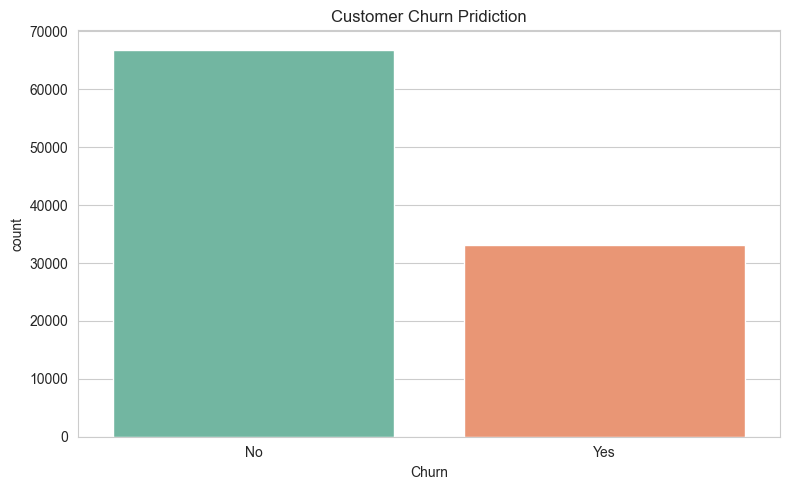

In [75]:
churnrate = df['Churn_Flag'].mean()*100
print(f"Overall Churn Rate: {churnrate:.2f}%")
sns.countplot(data=df,x='Churn',palette='Set2')
plt.title("Customer Churn Pridiction")
plt.tight_layout()
plt.show()

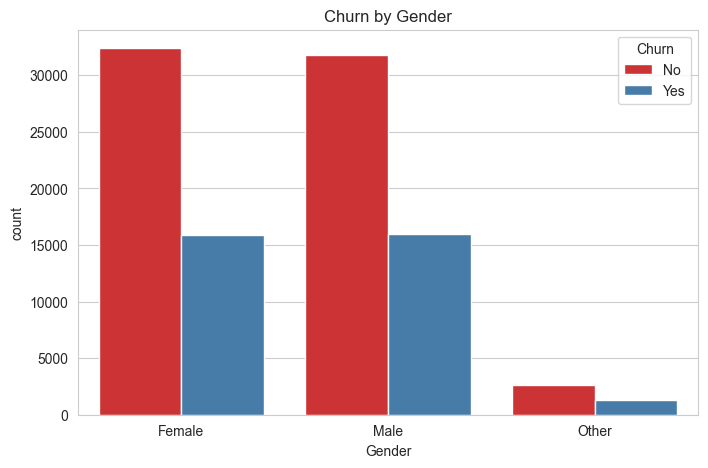

In [76]:
# Gender wise churn  
sns.countplot(data=df, x='Gender',hue='Churn', palette='Set1')
plt.title("Churn by Gender")
plt.show()

3- Tenure and Churn relation 

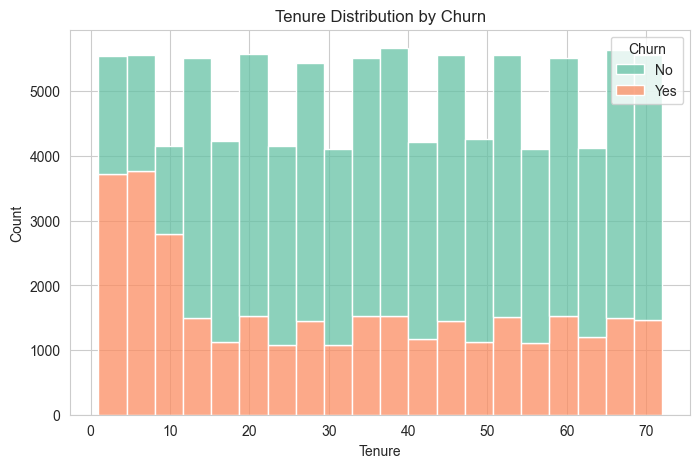

In [78]:
sns.histplot(data=df,x='Tenure',hue='Churn',multiple='stack',bins=20,palette='Set2')
plt.title('Tenure Distribution by Churn')
plt.show()

<Axes: xlabel='Churn', ylabel='Tenure'>

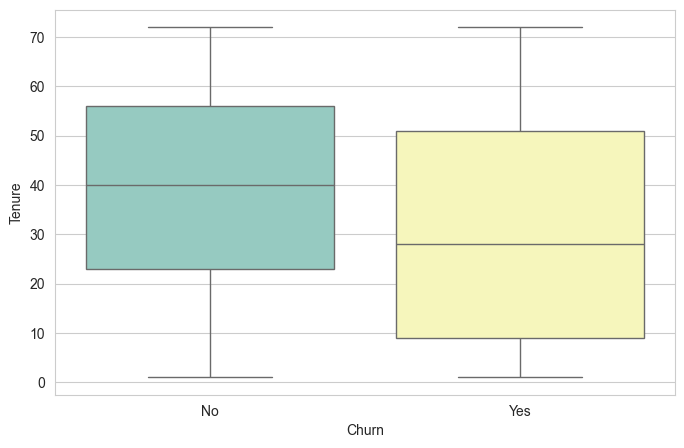

In [ ]:
sns.boxplot(data=df,x='Churn',y='Tenure',palette='Set3')
plt.title("Tenure Spread : Churned vs Retained")

4- Contract type churn

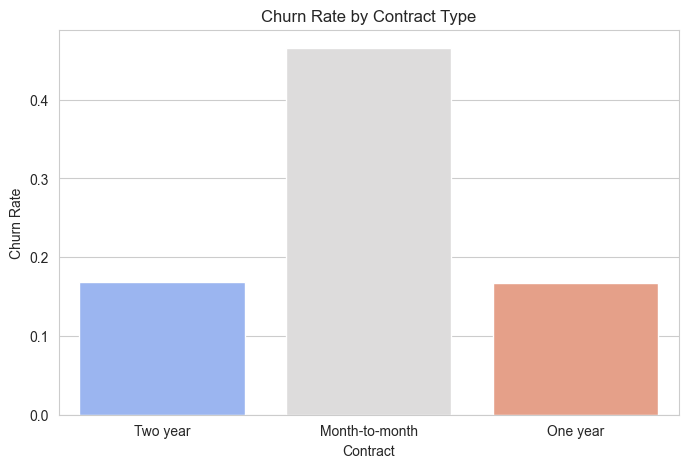

Contract
Month-to-month    46.557407
Two year          16.878531
One year          16.749139
Name: Churn_Flag, dtype: float64


In [82]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Contract', y='Churn_Flag', palette='coolwarm',ci=None)
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.show()

print(df.groupby('Contract')['Churn_Flag'].mean().sort_values(ascending=False) * 100)

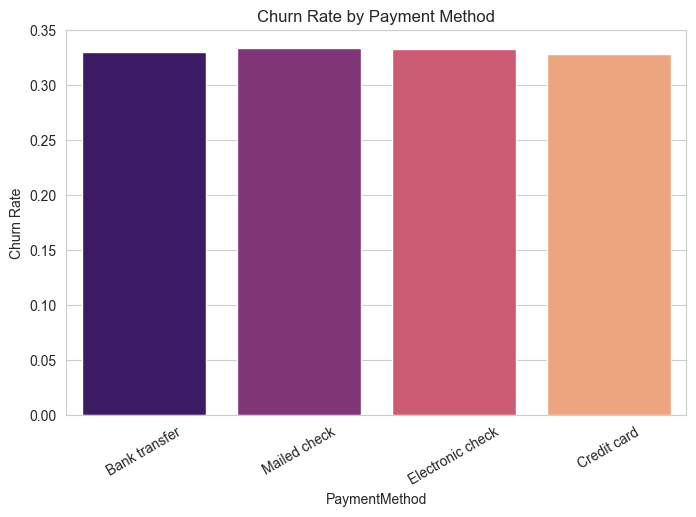

In [86]:
# Payment method affect churn 
sns.barplot(data=df, x='PaymentMethod', y='Churn_Flag', palette='magma', ci=None)
plt.xticks(rotation=30)
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Payment Method")
plt.show()

INSIGHT - Analysis shows that payment methods have a uniform churn rate of 33% . Hence , payment method in not a primary one . 

ques - MONTHLY CHARGES HIGH AFFECT CHURN

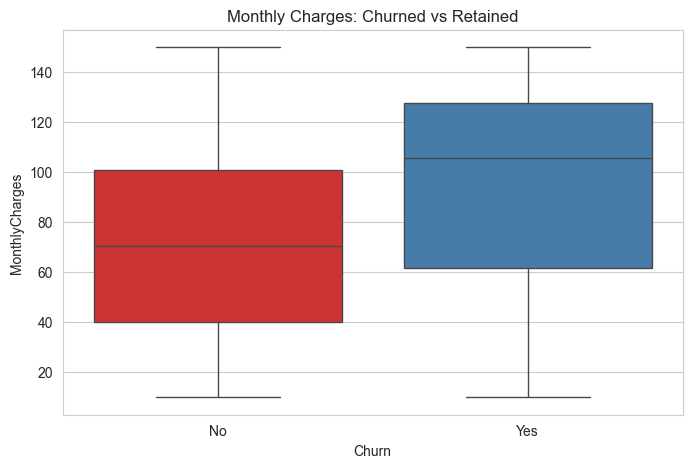

In [88]:
sns.boxplot(data=df,x='Churn', y='MonthlyCharges', palette='Set1')
plt.title("Monthly Charges: Churned vs Retained")
plt.show()

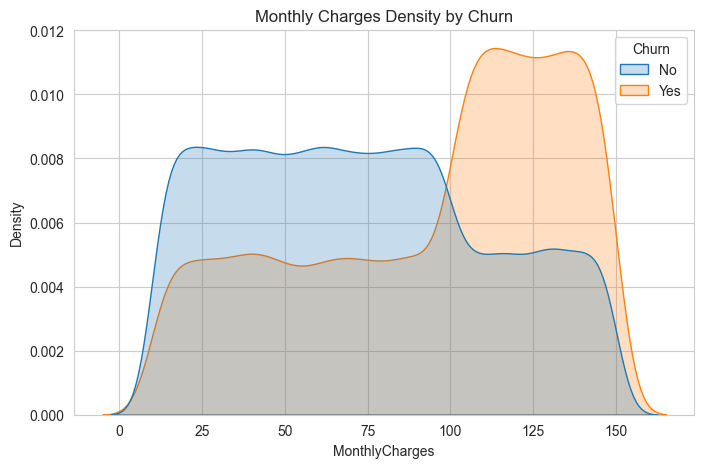

In [91]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False)
plt.title("Monthly Charges Density by Churn")
plt.show()

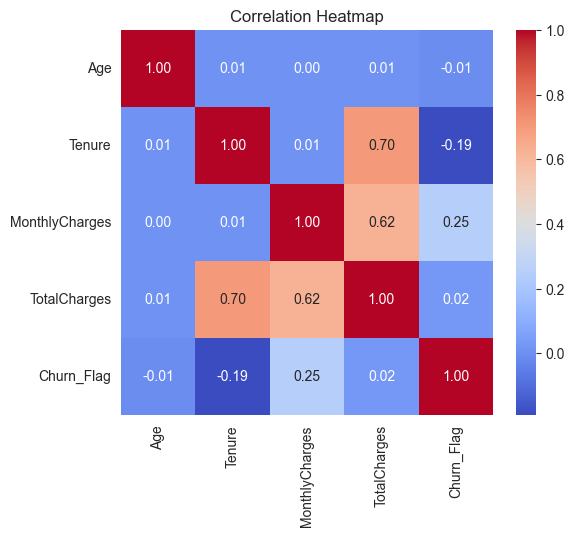

In [92]:
plt.figure(figsize=(6,5))
corr = df[['Age','Tenure','MonthlyCharges','TotalCharges','Churn_Flag']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

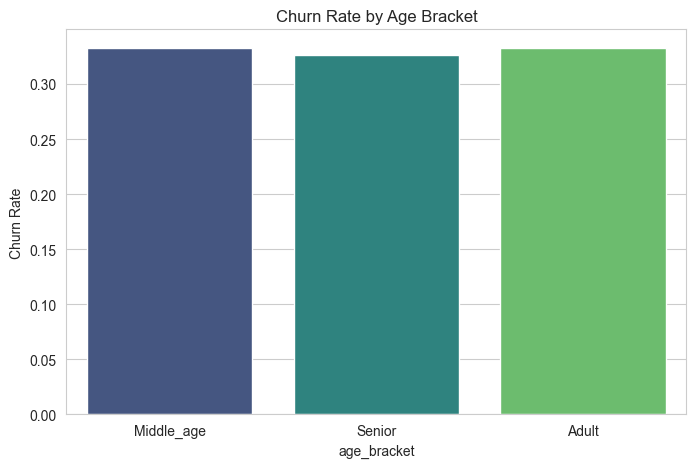

In [93]:
sns.barplot(data=df, x='age_bracket', y='Churn_Flag', palette='viridis', ci=None)
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Age Bracket")
plt.show()


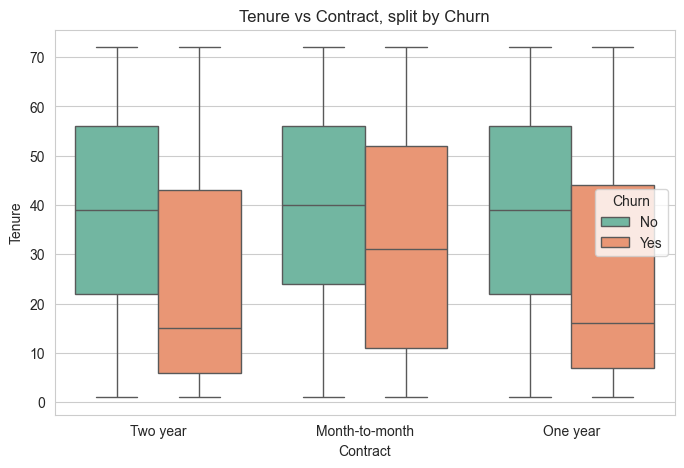

In [94]:
sns.boxplot(data=df, x='Contract', y='Tenure', hue='Churn', palette='Set2')
plt.title("Tenure vs Contract, split by Churn")
plt.show()

Chi - square test 


In [97]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Contract'], df['Churn'])
print(table)



Churn              No    Yes
Contract                    
Month-to-month  29348  25567
One year        21030   4231
Two year        16478   3346


In [98]:
chi2, p, dof, exp = chi2_contingency(table)
print(f"Chi-square value: {chi2:.2f}")
print(f"p-value: {p:.4f}")

Chi-square value: 9889.98
p-value: 0.0000


In [99]:
table2 = pd.crosstab(df['PaymentMethod'], df['Churn'])
chi2, p, dof, exp = chi2_contingency(table2)
print(f"PaymentMethod p-value: {p:.4f}")

PaymentMethod p-value: 0.5666


In [100]:
# Gender
table3 = pd.crosstab(df['Gender'], df['Churn'])
chi2, p, dof, exp = chi2_contingency(table3)
print(f"Gender p-value: {p:.4f}")

Gender p-value: 0.1331


REVENUE AT RISK

In [105]:
revenue_at_risk = df[df['Churn_Flag']==1]['MonthlyCharges'].sum()
total_revenue = df['MonthlyCharges'].sum()
risk_pct = (revenue_at_risk / total_revenue) * 100
print(f"Monthly Revenue at Risk: ₹{revenue_at_risk:,.0f}")
print(f"% of Total Revenue at Risk: {risk_pct:.2f}%")


Monthly Revenue at Risk: ₹3,127,312
% of Total Revenue at Risk: 39.10%


Segment wise Revenue loss 



In [106]:
segment_loss = df[df['Churn_Flag']==1].groupby('Contract')['MonthlyCharges'].sum().sort_values(ascending=False)
print(segment_loss)

Contract
Month-to-month    2307170.43
One year           459461.02
Two year           360680.56
Name: MonthlyCharges, dtype: float64


RISK SCORE

Risk_Level
Medium    53335
Low       38247
High       8418
Name: count, dtype: int64


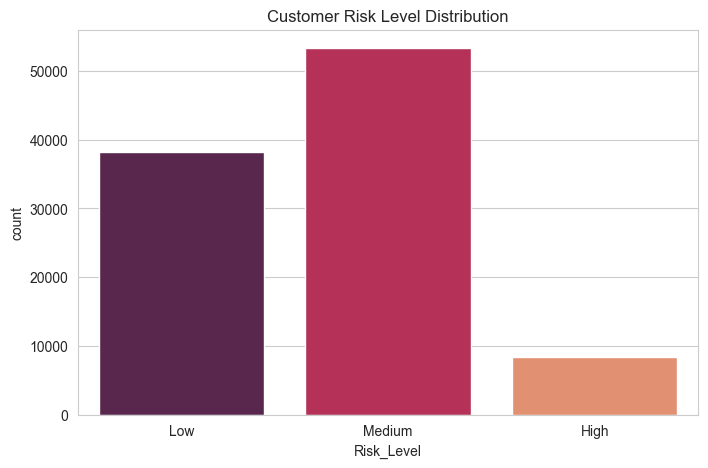

In [107]:
df['Risk_Score'] = (
    (df['Contract'] == 'Month-to-month').astype(int) * 2 +
    (df['Tenure'] < 12).astype(int) * 2 +
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int) * 1
)
df['Risk_Level'] = pd.cut(df['Risk_Score'], bins=[-1,1,3,5], labels=['Low','Medium','High'])
print(df['Risk_Level'].value_counts())

sns.countplot(data=df, x='Risk_Level', order=['Low','Medium','High'], palette='rocket')
plt.title("Customer Risk Level Distribution")
plt.show()

df.to_csv("final_churn_with_insights.csv", index=False)

Univariate (Churn rate, Gender, Age)
Bivariate (Contract, Payment, Tenure)
Correlation heatmap
Multivariate (Contract+Tenure+Churn)
Statistical test (Chi-square)
Revenue impact (business number)
Risk scoring (actionable output)

Insight: Month-to-month customers churn at 46.56% vs ~17% for long-term 
contracts. Contract type is a strong churn driver (Chi-square p<0.05).